#Paso 1:
#Dataset elegido:

#**Agrupación de Clientes**
Modelo de agrupamiento para la ciencia de datos.


**Justificación:**
El dataset elegido presenta información básica obtenida de los clientes de una línea de supermercados con distintas sucursales a nivel departamental. Lo elegimos porque nos permite analizar las características y perfiles de los clientes, siendo así el objetivo, realizar una captación de clientes, tomando en cuenta que nuestro análisis es no supervisado, no predeciremos una variable, sino buscaremos patrones que nos ayuden diseñar estrategias mas efectivas.

#Paso 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

df = pd.read_csv('/content/segmentation data.csv')


El primer paso fue hacer la importación de librerias y cargar el datset.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [3]:
df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [4]:
print(f"\nShape del dataset: {df.shape}")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")


Shape del dataset: (2000, 8)
Filas: 2000
Columnas: 8


In [5]:
df.isnull().sum()

,0
ID,0
Sex,0
Marital status,0
Age,0
Education,0
Income,0
Occupation,0
Settlement size,0


El dataset no presenta valores nulos.

In [6]:
print("Rango de las variables numéricas:")
display(df.describe().loc[['min', 'max']])

Rango de las variables numéricas:


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
min,100000001.0,0.0,0.0,18.0,0.0,35832.0,0.0,0.0
max,100002000.0,1.0,1.0,76.0,3.0,309364.0,2.0,2.0


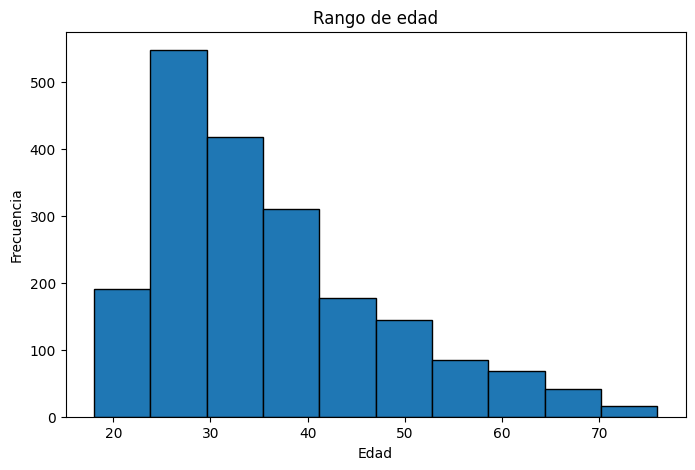

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=10, edgecolor='black')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Rango de edad')
plt.show()

En la primera parte, configuré el tamaño de la gráfica, posteriormente la agrupación de intérvalos. Finalmente las etiquetas para después mostrarlo.

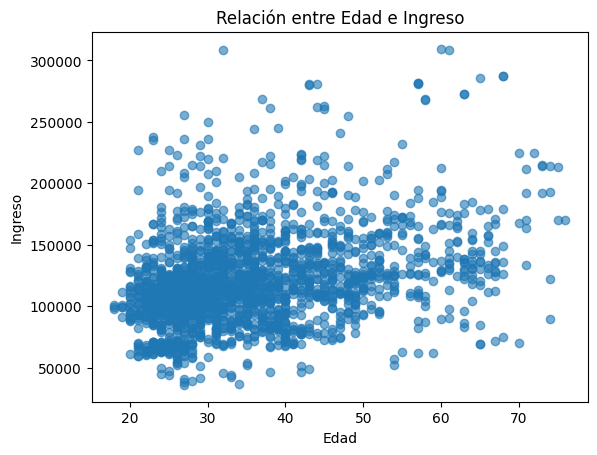

In [8]:
plt.scatter(df['Age'], df['Income'], alpha=0.6)
plt.xlabel('Edad')
plt.ylabel('Ingreso')
plt.title('Relación entre Edad e Ingreso')
plt.show()

Creamos el gráfico entre edad y el ingreso, tomando en cuenta que cada punto es un cliente. Los nombres de los ejes, que serían edad e ingreso y finalmente el título para luego mostrarlo.

#Justificación paso 2:
En la primer gráfica se puede ver en los resultados del rago de edad por freciencia, que existen más clientes entre los 25 a 35 años.
En la segunda, que es Relación entre edad e ingreso se puede observar que las mismas personas entre los 20 y 40 años presentan un ingreso de 50.000 a un poco más de 150.000.

#Paso 3:


In [9]:
cols = ['Age', 'Income', 'Settlement size']
X = df[cols]
print(f"\nVariables seleccionadas: {cols}")
print("\nRango de las variables:")
display(X.describe())


Variables seleccionadas: ['Age', 'Income', 'Settlement size']

Rango de las variables:


,Age,Income,Settlement size
count,2000.000000,2000.000000,2000.000000
mean,35.909000,120954.419000,0.739000
std,11.719402,38108.824679,0.812533
min,18.000000,35832.000000,0.000000
25%,27.000000,97663.250000,0.000000
50%,33.000000,115548.500000,1.000000
75%,42.000000,138072.250000,1.000000
max,76.000000,309364.000000,2.000000


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Escalado realizado correctamente.")

Escalado realizado correctamente.


# Justificación paso 3:
Se seleccionaron las variables: Edad, Ingreso y Tamaño de la ciudad, psoteriormente las almacené en la variable X, elegimos estas variables, ya que son importantes para identificar los grupos de clientes.
Se puede observar que se estan utilizando 2 variables numéricas, que son Edad e Ingreso y 1 variable categorizada que es Tamaño de la ciudad, siendo ésta variable codificada de forma numérica (0) ciudad pequeña, (1) ciudad mediana y (2) ciudad grande, para así aplicar al modelo. Estas variables juntas brindan informacion para que el algoritmo forme grupos de clientes con caracterísicas similares.
Después aplicamos el StandarScaler para poder estandarizar las variables.

# Paso 4:

In [11]:
inercias = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    print(f"k={k}: inercia={kmeans.inertia_:.1f}")

k=2: inercia=3670.4
k=3: inercia=2699.7
k=4: inercia=2202.2
k=5: inercia=1873.6
k=6: inercia=1606.2
k=7: inercia=1422.9
k=8: inercia=1290.2


1. En este paso probamos los valores K del 2 al 8, entrenando el K-means, con los datos escalados y se calculó su inercia.

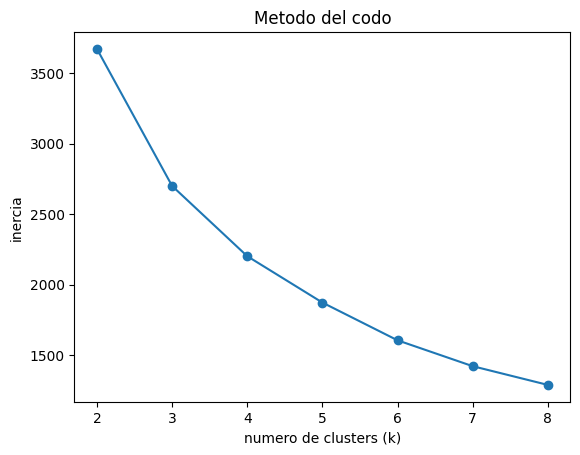

In [12]:
plt.plot(range(2, 9), inercias, marker='o')
plt.xlabel('numero de clusters (k)')
plt.ylabel('inercia')
plt.title('Metodo del codo')
plt.show()


2. Despues de calcular la inercia para cada K, se realizó el gráfico de la curva, que se forma un "codo". Se puede observar que la inercia disminuye a medida que aumenta el número de clústeres.

In [13]:
from sklearn.metrics import silhouette_score
siluetas =[]
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    silueta = silhouette_score(X_scaled, kmeans.labels_)
    siluetas.append(silueta)
    print(f"k={k}: silhouette={silueta:.1f}")

k=2: silhouette=0.4
k=3: silhouette=0.4
k=4: silhouette=0.4
k=5: silhouette=0.3
k=6: silhouette=0.4
k=7: silhouette=0.3
k=8: silhouette=0.3


3. Se calculó el Silhouette score, para los valores K entre 2 y 8, se puede observar que los valores se encuentran entre 0.3 y 0.4, formando un buen agrupamiento.

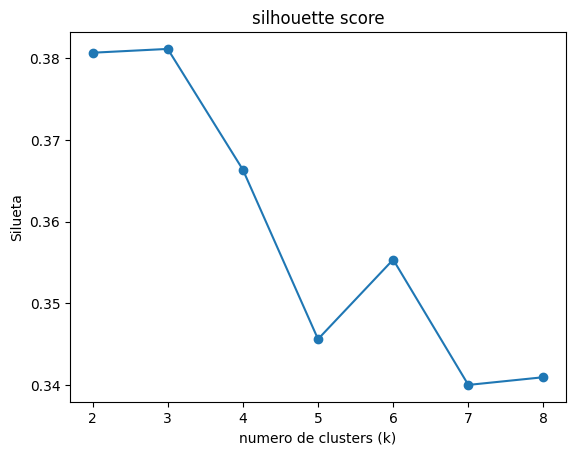

In [14]:
plt.plot(range(2, 9), siluetas, marker='o')
plt.xlabel('numero de clusters (k)')
plt.ylabel('Silueta')
plt.title('silhouette score')
plt.show()

Calculamos el silhouette score para poder graficarlo, la goráfica nos permte comparar el agrupamiento y ver con que valor K se tiene una mejor separación de grupos.

4. Elegimos el K4 ya que según el método del codo muestra que desde ese valor la reducción de la inercia se estabiliza y el silhouette muestra que K 4 tambien es el mas adecuado.

# Justificación paso 4:
Elegimos el K 4 porque el método del codo indicó mediante su grafica que es el punto donde el valor presenta la disminución de la bajada de la inercia. También tomando en cuenta que el resultado del coeficiente del Silhouette fue K 3 el mas alto pero K 4 es el resultado mas acertado. Tomando en cuenta que el 4 es el que tiene más equilibrio en los resultados.

# Paso 5

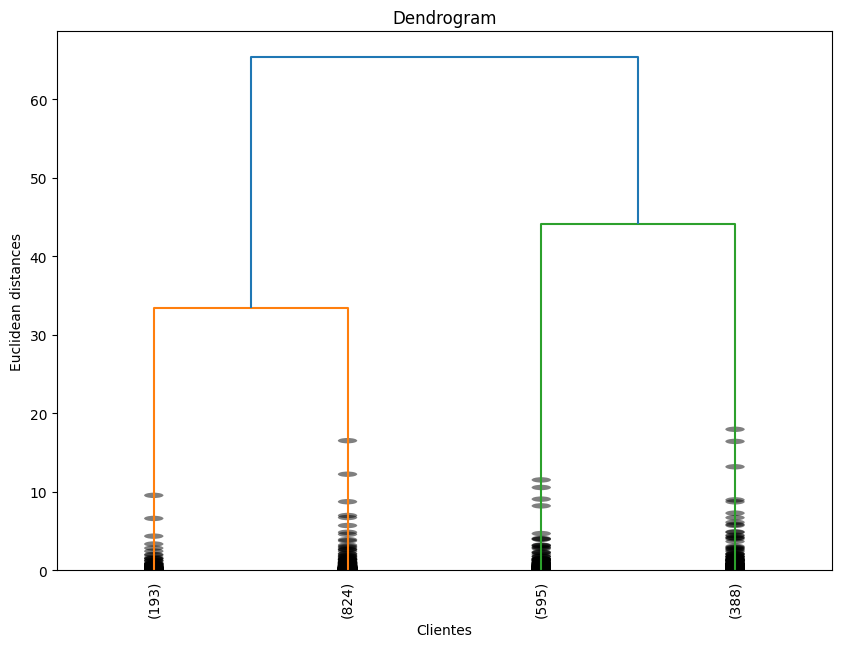

In [15]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(10, 7))
z = sch.linkage(X_scaled, method='ward')
dendrograma = sch.dendrogram(z,truncate_mode='lastp',p=4, leaf_rotation=90. ,leaf_font_size=10., show_contracted= True)
plt.title('Dendrogram')
plt.xlabel('Clientes')
plt.ylabel('Euclidean distances')
plt.show()

Aplicamos el metodo de agrupamiento jerarquico (Clustering) con el metodo WARD para realizar el Dendograma. Podemos ver en el grafico que los grupos de clientes se unen dependiendo de la distancia entre ellos.

In [16]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_kmeans'] = km4.fit_predict(X_scaled)
df['cluster_kmeans'].value_counts().sort_index()

,count
cluster_kmeans,
0,653
1,282
2,769
3,296


Aplicamos otra vez el KMeans con los 4 clusteres, asignando un cliente a un grupo y se conto los registros a los que pertenece cada cluster.
Se puede ver en la tabla que son de diferente tamaño cada grupo.

#Justificacion paso 5:
Podemos ver que el dendograma muestra que los datos pueden dividirse en varios grupos, como tambien vemos que para datos jerarquicos toma datos más parecidos entre sí, así los grupos de edades similares se agrupan, sin embargo para el modelo KMeans toma los datos mas cercanos de 1 y posteriormente los agrupa.

#Paso 6:

In [17]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

print("K-Means: encontró", len(set(df['cluster_kmeans'])), "clusters")
print("DBSCAN: encontró", len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0),
      "clusters +", list(clusters_dbscan).count(-1), "puntos marcados como ruido (-1)")

K-Means: encontró 4 clusters
DBSCAN: encontró 9 clusters + 31 puntos marcados como ruido (-1)


In [18]:
dbscan = DBSCAN(eps=0.4, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_scaled)

print("K-Means: encontró", len(set(df['cluster_kmeans'])), "clusters")
print("DBSCAN: encontró", len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0),
      "clusters +", list(clusters_dbscan).count(-1), "puntos marcados como ruido (-1)")

K-Means: encontró 4 clusters
DBSCAN: encontró 5 clusters + 128 puntos marcados como ruido (-1)


In [ ]:
dbscan = DBSCAN(eps=0.7, min_samples=3)
clusters_dbscan = dbscan.fit_predict(X_scaled)

print("K-Means: encontró", len(set(df['cluster_kmeans'])), "clusters")
print("DBSCAN: encontró", len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0),
      "clusters +", list(clusters_dbscan).count(-1), "puntos marcados como ruido (-1)")

La mejor base de DBSCAN es la que tiene menos OUTLINERS encontrados, ellos se presentan como informacion perdida si existe mucha información que no sea encontrada, o también se presenta como ruido.

#Paso 7

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print(varianza *100 )



[55.24805402 29.61380786]


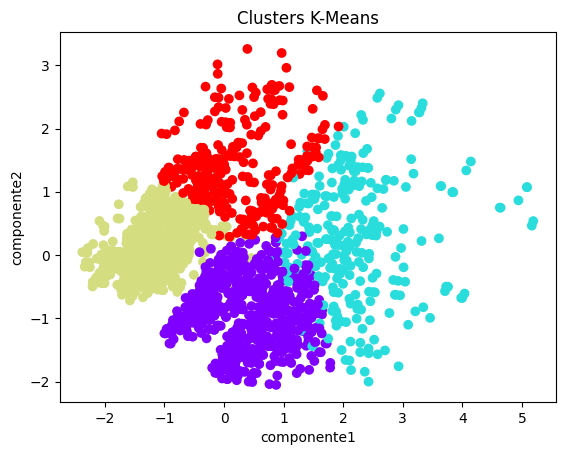

In [20]:
df_pca = pd.DataFrame(X_pca, columns=['componente1', 'componente2'])
df_pca['cluster_kmeans'] = df['cluster_kmeans']
plt.scatter(df_pca['componente1'], df_pca['componente2'], c=df_pca['cluster_kmeans'], cmap='rainbow')
plt.xlabel('componente1')
plt.ylabel('componente2')
plt.title('Clusters K-Means')
plt.show()

El porcentaje que conservan los 2 componentes es aproximadamente un 84% de la información, siendo original, esto quiere decir que se puede confiar en el modelo para poder realizar predicciones.

#Paso 8:

In [21]:
df.groupby('cluster_kmeans')[cols].mean().round(1)

,Age,Income,Settlement size
cluster_kmeans,,,
0,30.6,124880.8,1.5
1,49.2,182460.6,1.5
2,29.7,96727.3,0.0
3,51.1,116636.8,0.3


Los clusters encontrados coinciden, ya que podemos observar que no cuenta con mucha información perdida al realizar los clusters.
Para poder usar estos clusters en una decisión real, podriamos observar que los clientes con mayores compras son aquellos con edades entre los 30 años y 49 años. Éstas compras también se destacan más en ciudades pequeñas o medianas, es decir, se pueden hacer campañas publicitarias para dichas ciudades para que los clientes puedan comprar más de lo que lo hacían.
La limitación del análisis puede ser, saber cada cuánto es recurrente las ventas, si mis clientes son recurrentes en venir a comprar o si es de manera convencional. Una variable adicional podria haber sido (dias_ultima_compra)